In [72]:
from langgraph.graph import StateGraph, END, START
from typing_extensions import TypedDict

In [ ]:
class PrivateState(TypedDict):
    a: int
    b: int
    c: int


class InputState(TypedDict):
    hello: str


class OutputState(TypedDict):
    bye: str


class MegaPrivate(TypedDict):
    secret: str


graph_builder = StateGraph(
    PrivateState,
    input_schema=InputState,
    output_schema=OutputState,
)

In [79]:
def node_one(state: InputState) -> InputState:
    print("node_one ->", state)
    return InputState(
        hello="world",
    )


def node_two(state: PrivateState) -> PrivateState:
    print("node_two ->", state)
    return PrivateState(
        a=1,
    )


def node_three(state: PrivateState) -> PrivateState:
    print("node_three ->", state)
    return PrivateState(
        b=1,
    )


def node_four(state: PrivateState) -> OutputState:
    print("node_four ->", state)
    return OutputState(bye="bye")


def node_five(state: OutputState) -> MegaPrivate:
    return MegaPrivate(
        secret="True",
    )


def node_six(state: MegaPrivate) -> None:
    print(state)

In [80]:
graph_builder.add_node("node_one", node_one)
graph_builder.add_node("node_two", node_two)
graph_builder.add_node("node_three", node_three)
graph_builder.add_node("node_four", node_four)
graph_builder.add_node("node_five", node_five)
graph_builder.add_node("node_six", node_six)

graph_builder.add_edge(START, "node_one")
graph_builder.add_edge("node_one", "node_two")
graph_builder.add_edge("node_two", "node_three")
graph_builder.add_edge("node_three", "node_four")
graph_builder.add_edge("node_four", "node_five")
graph_builder.add_edge("node_five", "node_six")
graph_builder.add_edge("node_six", END)

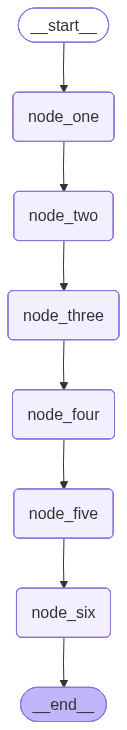

In [81]:
graph = graph_builder.compile()

graph

In [82]:
graph = graph_builder.compile()

result = graph.invoke(
    {
        "hello": "world",
    },
)

print("result", result)

node_one -> {'hello': 'world'}
node_two -> {}
node_three -> {'a': 1}
node_four -> {'a': 1, 'b': 1}
{'secret': 'True'}
result {'bye': 'bye'}


### Reducer Function

In [ ]:
from langgraph.graph import StateGraph, END, START
from typing_extensions import TypedDict
from typing import Annotated

from langgraph.types import CachePolicy
from langgraph.cache.memory import InMemoryCache

import operator

In [113]:
def update_function(old, new):
    # print("old -> ", old)
    # print("new -> ", new)
    return old + new


class State(TypedDict):
    # messages: Annotated[list[str], update_function]
    messages: Annotated[list[str], operator.add]


graph_builder = StateGraph(State)

In [114]:
def node_one(state: State):
    # last_message = state["messages"][-1]
    # return {
    #     "messages": state["messages"]
    #     + [
    #         "Hello, nice to meet you!",
    #     ],
    # }
    return {"messages": ["hello, nice to meet you!"]}


def node_two(state: State):
    print(state)

In [ ]:
graph_builder.add_node("node_one", node_one)
graph_builder.add_node(
    "node_two",
    node_two,
    cache_policy=CachePolicy(
        ttl=20,
    ),
)

graph_builder.add_edge(START, "node_one")
graph_builder.add_edge("node_one", "node_two")
graph_builder.add_edge("node_two", END)

In [ ]:
graph = graph_builder.compile(cache=InMemoryCache())

result = graph.invoke(
    {"messages": ["hello"]},
)

{'messages': ['hello', 'hello, nice to meet you!']}


In [ ]:
from langgraph.graph import StateGraph, END, START
from typing_extensions import TypedDict, Union, Annotated
from langgraph.types import Send, Command

import operator

In [13]:
class State(TypedDict):
    words: list[str]
    output: Annotated[list[dict[str, Union[str, int]]], operator.add]


graph_builder = StateGraph(State)

In [14]:
def node_one(state: State):
    print(state["words"])
    return {"messages": ["hello, nice to meet you!"]}


def node_two(word: str):
    return {
        "output": [
            {
                "word": word,
                "letters": len(word),
            }
        ]
    }

In [15]:
graph_builder.add_node("node_one", node_one)
graph_builder.add_node("node_two", node_two)


def dispatcher(state: State):
    # words = state["words"]
    # sends = []
    # for word in words:
    #     sends.append(Send("node_two", word))

    # return sends

    return [Send("node_two", word) for word in state["words"]]


graph_builder.add_edge(START, "node_one")
graph_builder.add_conditional_edges("node_one", dispatcher, ["node_two"])
graph_builder.add_edge("node_two", END)

In [17]:
graph = graph_builder.compile()

result = graph.invoke(
    {
        "words": ["hello", "1", "22", "333"],
    },
)

result

['hello', '1', '22', '333']


{'words': ['hello', '1', '22', '333'],
 'output': [{'word': 'hello', 'letters': 5},
  {'word': '1', 'letters': 1},
  {'word': '22', 'letters': 2},
  {'word': '333', 'letters': 3}]}

In [36]:
from langgraph.graph import StateGraph, END, START
from typing_extensions import TypedDict, Union, Annotated
from langgraph.types import Command, Literal

import operator

In [37]:
class State(TypedDict):
    transfer_reson: str


graph_builder = StateGraph(State)

In [38]:
def node_one(state: State) -> Command[Literal["node_two", "node_three"]]:
    return Command(
        goto="node_two",
        update={
            "transfer_reson": "The user wants to change password.",
        },
    )


def node_two(state: State):
    return {}


def node_three(state: State):
    return {}

In [39]:
graph_builder.add_node("node_one", node_one)
graph_builder.add_node("node_two", node_two)
graph_builder.add_node("node_three", node_three)


graph_builder.add_edge(START, "node_one")

graph_builder.add_edge("node_two", END)
graph_builder.add_edge("node_three", END)

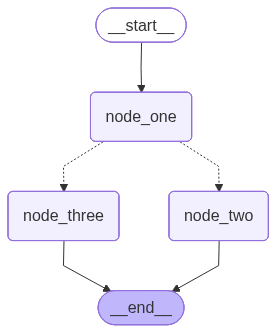

In [40]:
graph = graph_builder.compile()

graph

In [ ]:
graph.invoke()

### LangGraph Chat Bot

In [13]:
from langgraph.graph import StateGraph, END, START
from langchain.chat_models import init_chat_model
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages, MessagesState

from typing_extensions import TypedDict, Annotated

import operator

llm = init_chat_model("openai:gpt-4o-mini")

llm.invoke(
    [
        {"role": "user", "content": "hello"},
    ],
)

AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 8, 'total_tokens': 17, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_7fa0fbf23d', 'id': 'chatcmpl-Do2dSl029RZOOoQ5o8d04TPhSr07u', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--019ea113-fae7-7040-94fe-f35067fc0686-0', usage_metadata={'input_tokens': 8, 'output_tokens': 9, 'total_tokens': 17, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [ ]:
# class State(TypedDict):
#     messages: Annotated[list[AnyMessage], add_messages]


class State(MessagesState):
    custom_stuff: str


graph_builder = StateGraph(State)

In [10]:
def chatbot(state: State):
    response = llm.invoke(state["messages"])
    return {
        "messages": [response],
    }

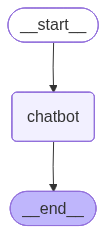

In [11]:
graph_builder.add_node("chatbot", chatbot)

graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)


graph = graph_builder.compile()

graph

In [12]:
graph.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "how are you?",
            },
        ],
    },
)

{'messages': [HumanMessage(content='how are you?', additional_kwargs={}, response_metadata={}, id='cce03f0e-d8cd-4336-800b-0cc76e3acd3d'),
  AIMessage(content="I'm just a program, so I don't have feelings, but I'm here and ready to help you! How can I assist you today?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 11, 'total_tokens': 38, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_4dafa39984', 'id': 'chatcmpl-Do2ZfVOWOl8jrArC8ahicv8YpklX5', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--019ea110-6606-7d72-aa9f-777d8dbbe643-0', usage_metadata={'input_tokens': 11, 'output_tokens': 27, 'total_tokens': 38, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'outp